In [1]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']

#from model import *
import model as mod
import model
from utils import *

In [2]:
path_exp = '../results/experiments/'

In [3]:
openai.__version__

'1.50.2'

In [4]:
# set simulation parameters
seed = 0
np.random.seed(seed)
noise_mean = 0
noise_sd = 1/4
temperature = 1
memory = 3
instruction_type = 'original_30-50w'
n_agents = 5
n_steps = 3
gpt_model="gpt-4"
#gpt_model="gpt-3.5-turbo-0125"

# Positive feedback

In [5]:
expmnt_num = 0
feedback='pos'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

File expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_3_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed.


In [6]:
#op =original positive
gpt_model = "gpt-4-1106-preview"
# gpt_model="gpt-3.5-turbo-0125"
# gpt_model="gpt-4"
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will predict the initial price to be in the medium range as there are no specific market trends or information available for this first period.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As it\'s the first time step, I\'ll base my prediction on an average historical price that provides a stable starting point.",\n  "predictedValue": 50\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n    "reasoning": "I will make an initial conservative prediction close to the historical average price to minimize errors in the first period.",\n    "predictedValue": 50.00

OSError: Cannot save file into a non-existent directory: '..\results\experiments'

In [7]:
#op =original positive
gpt_model = "gpt-4-0125-preview"
# gpt_model="gpt-3.5-turbo-0125"
# gpt_model="gpt-4"
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n\t"reasoning": "Given the lack of historical data and uncertainty, I start with a neutral prediction of 50 euros for the initial price.",\n\t"predictedValue": 50\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a conservative estimate based on historical trends and the initial market conditions.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As the initial price is unknown, I will make a baseline prediction based on the average price of similar products in the market, which is typically in a moderate range to avoid extreme predictions initial

OSError: Cannot save file into a non-existent directory: '..\results\experiments'

In [8]:
pe_agents_time_op

NameError: name 'pe_agents_time_op' is not defined

In [9]:
p_array_op

NameError: name 'p_array_op' is not defined

In [10]:
#op =original positive
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n    "reasoning": "As there is no historical data available, I will make an initial prediction based on a neutral starting point. I will predict the initial price as 50 euros, the middle point of the price range.",\n    "predictedValue": 50\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Based on the initial conditions, I predict the market price will be in the mid-range around 50 euros.",\n  "predictedValue": 50\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As it is the first time step and no historical data is available, I predict a starting price at 50 euros.",\n  "predictedValue": 50

OSError: Cannot save file into a non-existent directory: '..\results\experiments'

In [11]:
pe_agents_time_op.shape

(5, 50)

Text(0.5, 0, 'Time step')

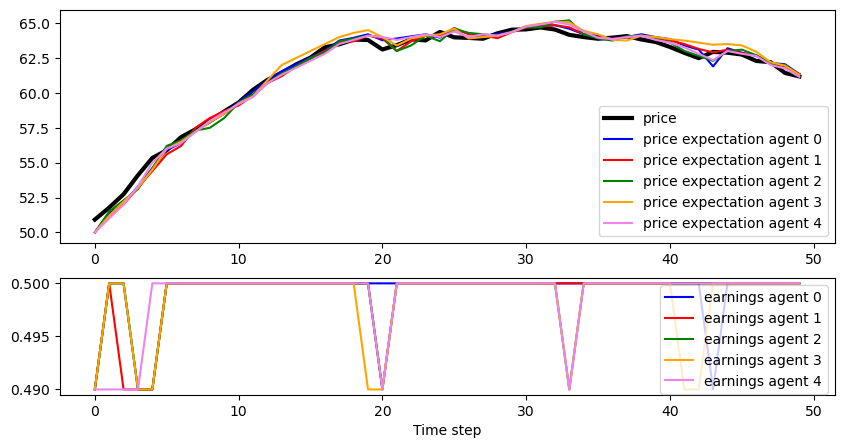

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_op,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_op[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_op[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

Text(0.5, 0, 'Time step')

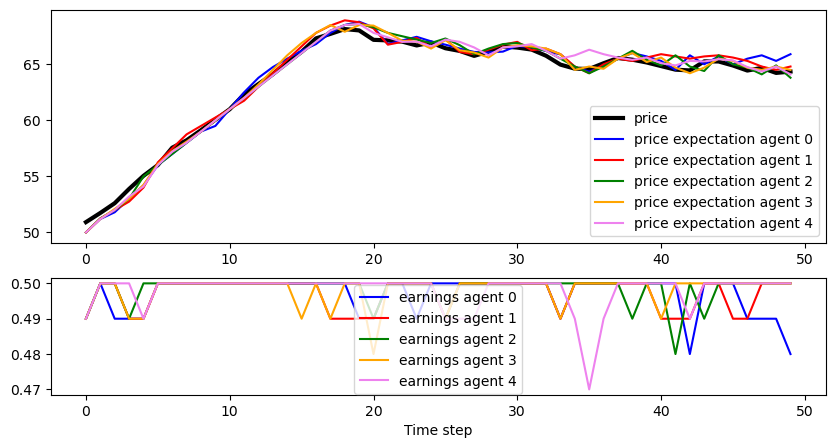

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_op,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_op[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_op[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

# Negative feedback

In [5]:
expmnt_num = 1
feedback='neg'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, n_steps, n_agents)

File expmnt_results_neg_original_30-50w_num_1_temp_1_ntime_50_nagents_5.csv does not exist. Safe to proceed.


In [6]:
#on =original negative
p_array_on, pe_agents_time_on, rewards_agents_time_on, messages_list_on  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {
  "reasoning": "I predict the initial market price to be around the average of historical prices as a starting point.",
  "predictedValue": 50
}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {
  "reasoning": "I predict that the initial market price will be close to the historical average of the product's price, as a starting point for further analysis.",
  "predictedValue": 50.00
}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {
    "reasoning": "I will start with a moderate price prediction close to the historical average as a baseline in the absence of specific trend information.",
    "predictedValue": 50.00
}
 
 Time: 0, agent: 3 

{'role': 'user', 'content': 'This is the first time step, give an initi

Text(0.5, 0, 'Time step')

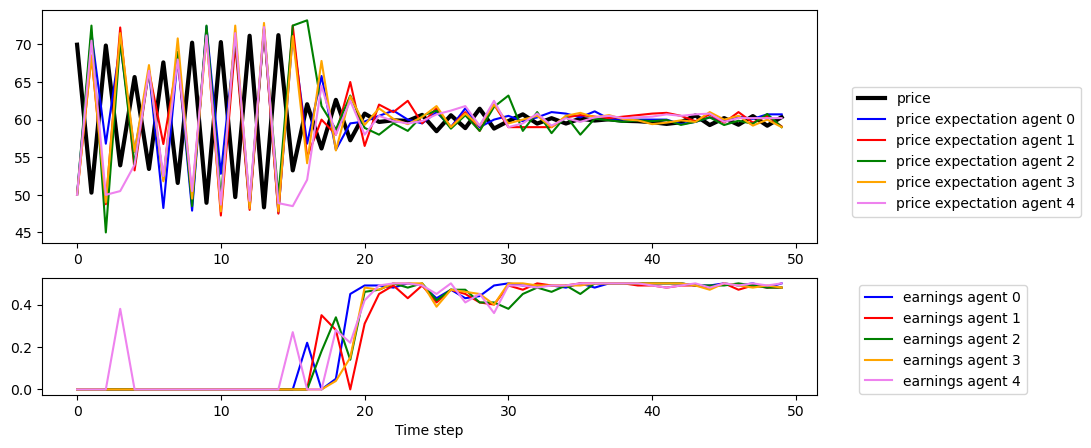

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_on,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_on[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_on[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend(bbox_to_anchor=(1.35, 0.7))
axes[1].legend(bbox_to_anchor=(1.28, 1))

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

In [21]:
df = pd.read_csv("../results/experiments/expmnt_results_pos_original_30-50w_num_1_temp_1_ntime_50_nagents_5.csv")

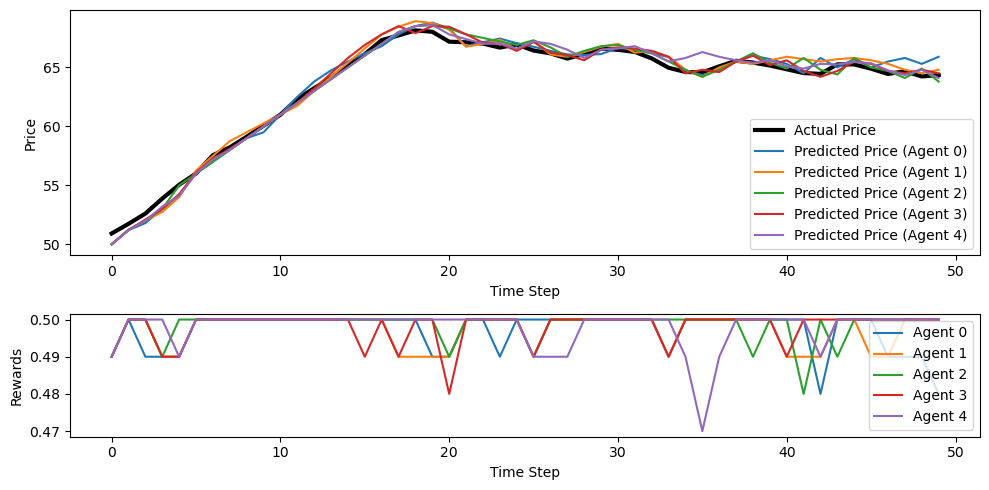

In [26]:
# Create figure and subplots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})

# Plot actual and predicted prices over time_step
axs[0].plot(df['time_step'], df['actual_price'], label='Actual Price', color="black",linewidth = 3)
for agent_id, group in df.groupby('agent_id'):
    axs[0].plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
axs[0].set_xlabel('Time Step')
axs[0].set_ylabel('Price')
axs[0].legend()

# Plot rewards by agent_id over time_step
for agent_id, group in df.groupby('agent_id'):
    axs[1].plot(group['time_step'], group['rewards'], label=f'Agent {agent_id}')
axs[1].set_xlabel('Time Step')
axs[1].set_ylabel('Rewards')
axs[1].legend()

plt.tight_layout()
plt.show()